In [21]:
import pandas as pd

df = pd.read_csv("Bank_Personal_Loan_Modelling.csv")

In [22]:
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  5000 non-null   int64 
 1   Age                 5000 non-null   int64 
 2   Experience          5000 non-null   int64 
 3   Income              5000 non-null   int64 
 4   ZIP Code            5000 non-null   int64 
 5   Family              5000 non-null   int64 
 6   CCAvg               5000 non-null   object
 7   Education           5000 non-null   int64 
 8   Mortgage            5000 non-null   int64 
 9   Personal Loan       5000 non-null   int64 
 10  Securities Account  5000 non-null   int64 
 11  CD Account          5000 non-null   int64 
 12  Online              5000 non-null   int64 
 13  CreditCard          5000 non-null   int64 
dtypes: int64(13), object(1)
memory usage: 547.0+ KB


Distribution Analysis

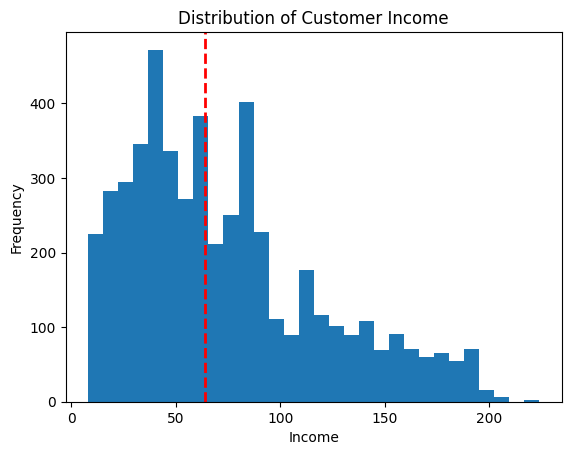

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['Income'], bins=30)

median_income = df['Income'].median()
plt.axvline(median_income, color='red', linestyle='dashed', linewidth=2)

plt.title('Distribution of Customer Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

Relationship Analysis

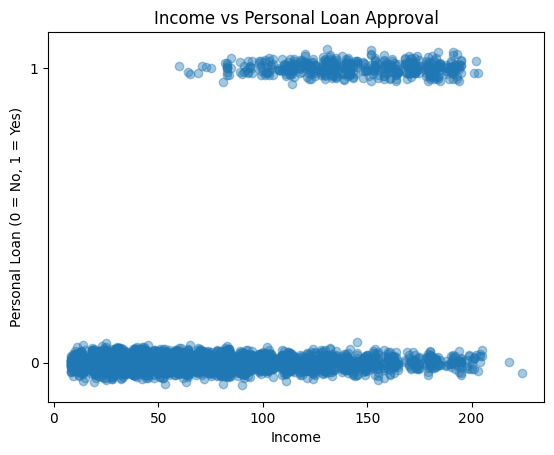

In [25]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(df['Income'], df['Personal Loan'] +
            np.random.normal(0, 0.02, len(df)),
            alpha=0.4)

plt.title('Income vs Personal Loan Approval')
plt.xlabel('Income')
plt.ylabel('Personal Loan (0 = No, 1 = Yes)')
plt.yticks([0, 1])

plt.show()

Categorical Analysis

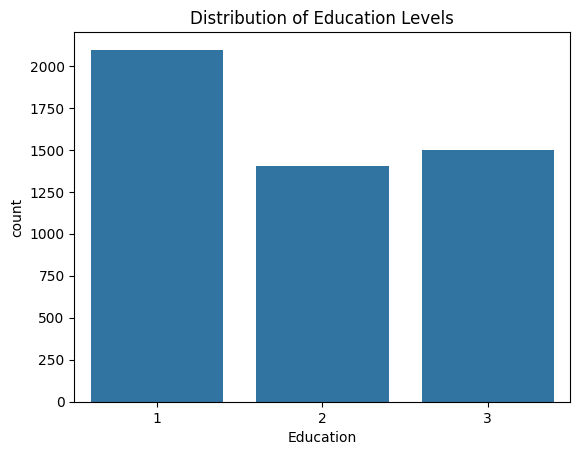

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# map values
edu_map = {1: 'Undergraduate', 2: 'Graduate', 3: 'Advanced'}

df['Education_Label'] = df['Education'].map(edu_map)

plt.figure()
sns.countplot(x='Education', data=df)
plt.title('Distribution of Education Levels')
plt.show()

Data Quality Check

In [27]:
#Missing Value
df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
Education_Label       0
dtype: int64

In [28]:
#Duplicate Check
df.duplicated().sum()
df[df.duplicated()]

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,Education_Label


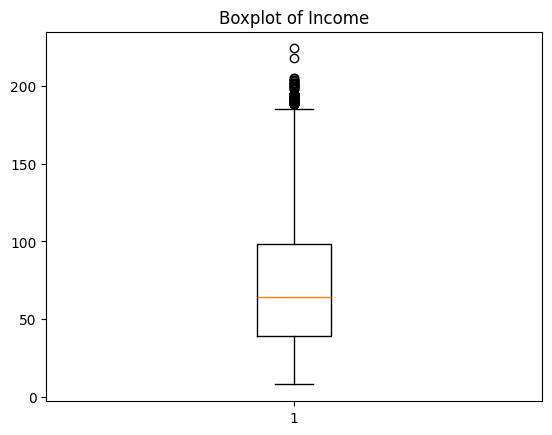

In [29]:
#Outlier Check
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df['Income'])
plt.title('Boxplot of Income')
plt.show()

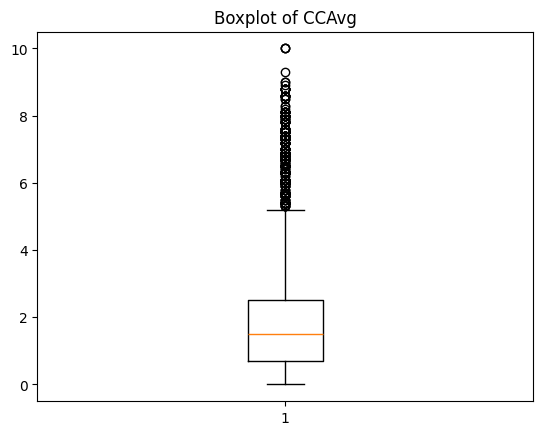

In [30]:
plt.figure()
df['CCAvg'] = df['CCAvg'].astype(str).str.replace('/', '.').astype(float)
plt.boxplot(df['CCAvg'])
plt.title('Boxplot of CCAvg')
plt.show()

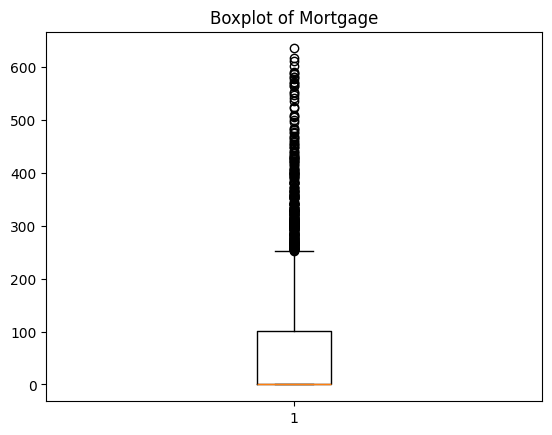

In [31]:
plt.figure()
plt.boxplot(df['Mortgage'])
plt.title('Boxplot of Mortgage')
plt.show()

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
 14  Education_Label     5000 non-null   object 
dtypes: float64(1), int64(13), object(1)
memory usage: 586.1

In [33]:
# Identify Categorical Column
df.nunique()

ID                    5000
Age                     45
Experience              47
Income                 162
ZIP Code               467
Family                   4
CCAvg                  108
Education                3
Mortgage               347
Personal Loan            2
Securities Account       2
CD Account               2
Online                   2
CreditCard               2
Education_Label          3
dtype: int64

Q2 (a)

In [34]:
#Standard Scaling
from sklearn.preprocessing import StandardScaler

numerical_cols = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']

scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df_scaled[numerical_cols].head()
df_scaled[numerical_cols].describe()

,Age,Experience,Income,CCAvg,Mortgage
count,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03
mean,-2.131628e-18,-1.179501e-16,1.449507e-16,-6.394885e-17,-5.613288e-17
std,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00
min,-1.948906e+00,-2.014911e+00,-1.428969e+00,-1.108987e+00,-5.555239e-01
25%,-9.019702e-01,-8.812043e-01,-7.554825e-01,-7.084116e-01,-5.555239e-01
50%,-2.952359e-02,-9.121982e-03,-2.123482e-01,-2.506106e-01,-5.555239e-01
75%,8.429230e-01,8.629604e-01,5.263146e-01,3.216407e-01,4.375576e-01
max,1.889859e+00,1.996667e+00,3.263712e+00,4.613525e+00,5.688108e+00


In [35]:
#Log Transformation
import numpy as np

df_scaled['Income_log'] = np.log1p(df['Income'])

print(df[['Income']].head())
print(df_scaled[['Income_log']].head())

print("Original Income skewness:", df['Income'].skew())
print("Log-transformed Income skewness:", np.log1p(df['Income']).skew())

   Income
0      49
1      34
2      11
3     100
4      45
   Income_log
0    3.912023
1    3.555348
2    2.484907
3    4.615121
4    3.828641
Original Income skewness: 0.8413386072610816
Log-transformed Income skewness: -0.42071189305490625


Develop Baseline Model (Logistic Regression)

In [39]:
from sklearn.model_selection import train_test_split

if 'Education_Label' in df_scaled.columns:
    df_scaled = df_scaled.drop('Education_Label', axis=1)

X = df_scaled.drop('Personal Loan', axis=1)
y = df_scaled['Personal Loan']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [40]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

/Users/janyin/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/janyin/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/janyin/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/janyin/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/janyin/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_

LogisticRegression(max_iter=1000)

In [41]:
y_pred = baseline_model.predict(X_test)

/Users/janyin/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/janyin/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/janyin/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Accuracy: 0.952

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97       895
           1       0.86      0.65      0.74       105

    accuracy                           0.95      1000
   macro avg       0.91      0.82      0.86      1000
weighted avg       0.95      0.95      0.95      1000



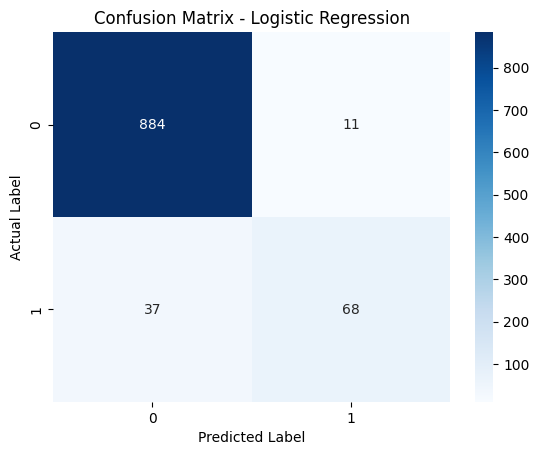

In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# plot heatmap
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

Improved Model (Random Forest)

In [44]:
from sklearn.ensemble import RandomForestClassifier

improved_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

improved_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [45]:
y_pred_rf = improved_model.predict(X_test)

Accuracy: 0.987

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       895
           1       0.98      0.90      0.94       105

    accuracy                           0.99      1000
   macro avg       0.98      0.95      0.96      1000
weighted avg       0.99      0.99      0.99      1000



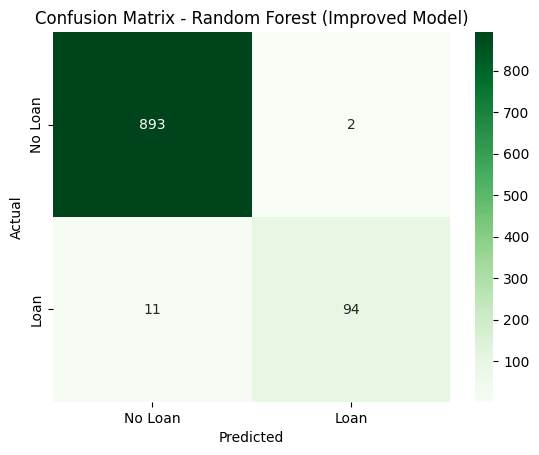

In [46]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Loan', 'Loan'],
            yticklabels=['No Loan', 'Loan'])

plt.title('Confusion Matrix - Random Forest (Improved Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
                                               

Q3 (a)

In [49]:
import pandas as pd

# 1) Missing values
missing_values = df.isnull().sum()

# 2) Duplicate rows
duplicate_rows = df.duplicated().sum()

# 3) Data types
data_types = df.dtypes

# 4) Value range checks
invalid_age = df[(df["Age"] < 18) | (df["Age"] > 100)]
invalid_income = df[df["Income"] < 0]
invalid_experience = df[df["Experience"] < 0]
invalid_mortgage = df[df["Mortgage"] < 0]

# Print results
print("Missing Values:\n", missing_values)
print("\nDuplicate Rows:", duplicate_rows)
print("\nData Types:\n", data_types)
print("\nInvalid Age Rows:", len(invalid_age))
print("Invalid Income Rows:", len(invalid_income))
print("Invalid Experience Rows:", len(invalid_experience))
print("Invalid Mortgage Rows:", len(invalid_mortgage))

Missing Values:
 ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

Duplicate Rows: 0

Data Types:
 ID                     int64
Age                    int64
Experience             int64
Income                 int64
ZIP Code               int64
Family                 int64
CCAvg                 object
Education              int64
Mortgage               int64
Personal Loan          int64
Securities Account     int64
CD Account             int64
Online                 int64
CreditCard             int64
dtype: object

Invalid Age Rows: 0
Invalid Income Rows: 0
Invalid Experience Rows: 52
Invalid Mortgage Rows: 0
